## **Importing Libraries and Preparing Data**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("brianmcabee/us-powerlifting-competition-data-2015now")
files = os.listdir(path)
df_raw = pd.read_csv(os.path.join(path, files[0]))

df = df_raw.copy()

print(df_raw.shape) # prints out the shape, ie. rows and columns of the dataframe
print(df_raw.info)


(179725, 38)
<bound method DataFrame.info of         Unnamed: 0               Name Sex Event Equipment   Age AgeClass  \
0          1306447    Billy Hernandez   M   SBD       Raw  24.0    24-34   
1           505543    Shon Paul Dukes   M   SBD       Raw  15.0    13-15   
2           505544   Michael Gintzler   M   SBD       Raw  20.5    20-23   
3           505546  Daniel Vanderberg   M   SBD       Raw  27.5    24-34   
4           505547           Ian Rowe   M   SBD       Raw  25.5    24-34   
...            ...                ...  ..   ...       ...   ...      ...   
179720     1342132          Steve Mar   M   SBD       Raw  33.0    24-34   
179721     1342135         Nick Smith   M   SBD       Raw  31.0    24-34   
179722     1342134   Ray DiBartolomeo   M   SBD       Raw  43.0    40-44   
179723     1342126       Elesia Jones   F   SBD       Raw  28.0    24-34   
179724     1342136   Ray DiBartolomeo   M   SBD       Raw  43.0    40-44   

       BirthYearClass       Division  Body

### unique() and reading data

- `df[['Sex','Equipment','Age','BodyweightKg']].unique()` only works on 1D single columns ie. df['Sex'].unique()
- **remember to make a copy of the original `.read_csv()` so if you fuck up the assignment you dont gotta redownload everything**

### dataframe filtering — df[filter]

`df[~df['Place'].astype(str).str.isdigit()]['Place'].unique()`
*~ (opposite) , df[place] read as string, filter if its a digit - if true, keep, otherwise, drop*

- because of the ~ we do the opposite of what is written, so likewise it will keep the letter values.

`df = df[df['Place'].astype(str).str.isdigit()]` filters out the letters - if the value in the place is a digit, it will keep, otherwise drop
- con: it may remove favoured values that we do not want removed, ie. negative numbers and decimal numbers

### dropna()

- the code `df = df.dropna` without any specific parameters, it will remove **all** rows that contain a single null column.
- parametize using `subset=`


## **Filtering and Cleaning Data**

In [2]:
df = df.dropna(subset=['Sex', 'Age', 'BodyweightKg', 'Equipment', 'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']) # drops any null values in the corresponding columns
df = df[pd.to_numeric(df['Place'], errors='coerce').notna()] # 
df = df[df['Federation'] == 'USPA']

df = df[(df['BodyweightKg'] > 50) & (df['BodyweightKg'] < 250)]
df = df[(df['Best3SquatKg'] > 0) & (df['Best3SquatKg'] < 500)]
df = df[(df['Best3BenchKg'] > 0) & (df['Best3BenchKg'] < 300)]
df = df[(df['Best3SquatKg'] > 0) & (df['Best3SquatKg'] < 500)]

df[['BodyweightKg', 'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']].describe()

df.to_csv('data/cleaned_data.csv')


## **EDA (Exploratory Data Analysis)**

### skew
- `Best3SquatKg` and `Best3DeadliftKg` does not have an apparent distribution skew
- `Best3BenchKg` has a Rightward distribution skew

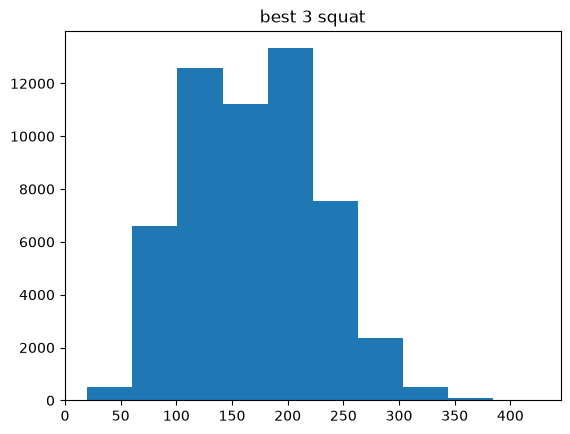

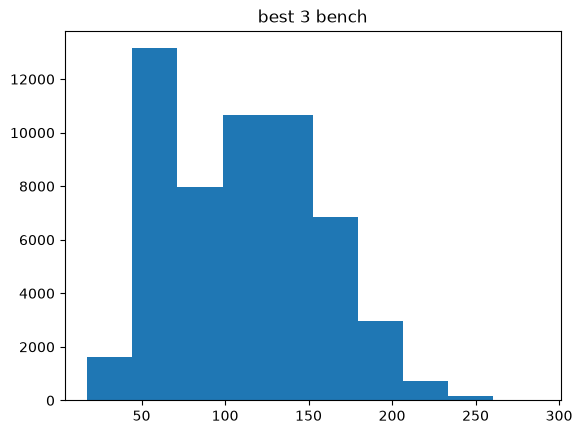

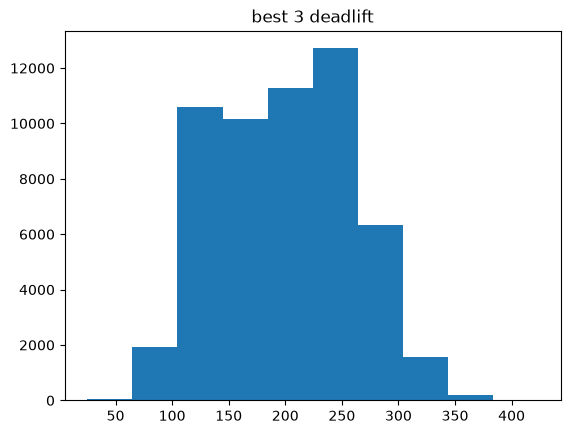

In [3]:
#print(df[['BodyweightKg', 'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']].describe())
#print(df[(df['Best3SquatKg'] >= 100) & (df['Best3SquatKg'] <= 150)].describe())

plt.hist(df["Best3SquatKg"])
plt.title("best 3 squat")
plt.show()

plt.hist(df["Best3BenchKg"])
plt.title("best 3 bench")
plt.show()

#logged_x = np.log(df['Best3BenchKg'])
#plt.hist(logged_x)
#plt.show()

plt.hist(df["Best3DeadliftKg"])
plt.title("best 3 deadlift")
plt.show()


### Lift vs Bodyweight by Sex

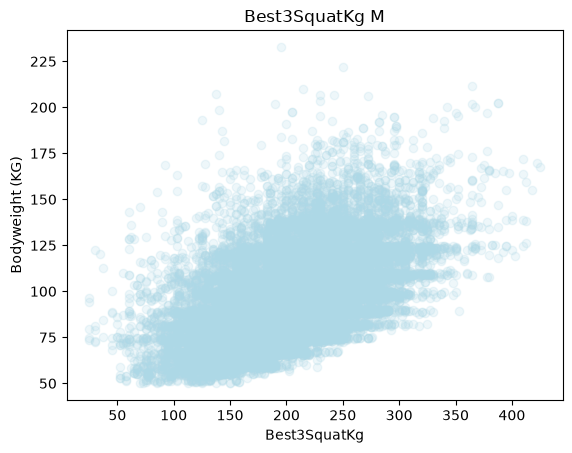

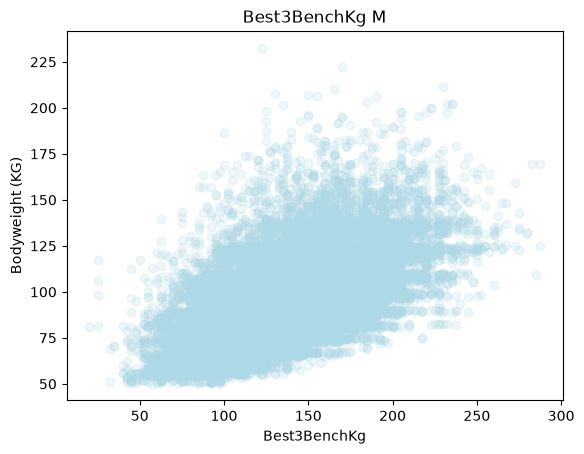

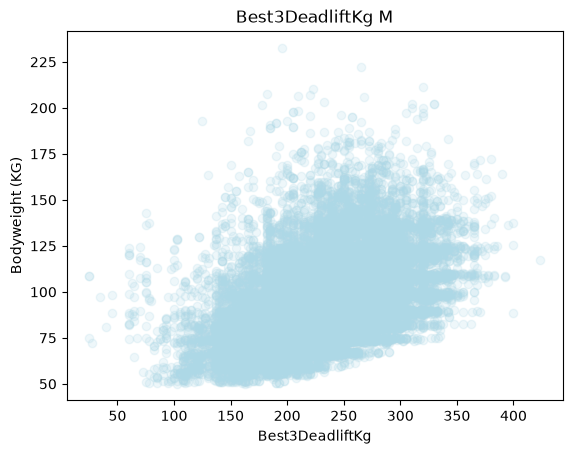

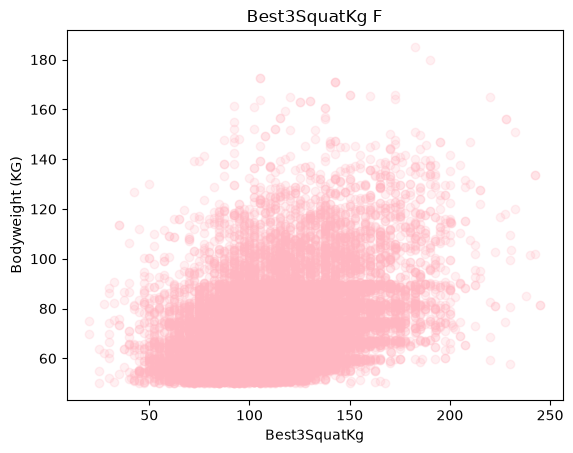

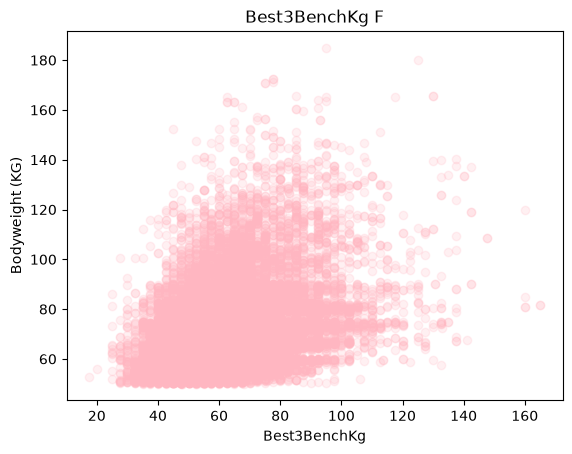

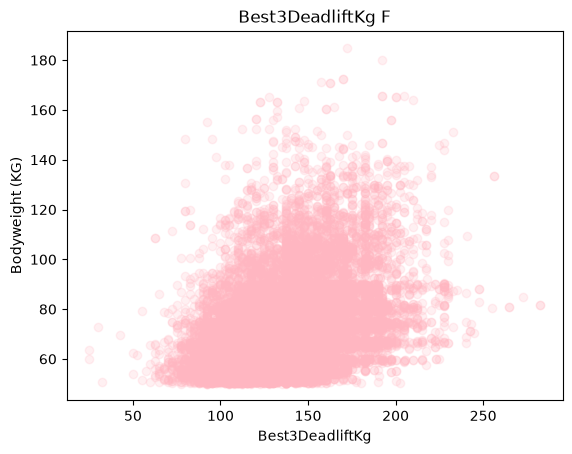

In [4]:
#df_m = df[df['Sex'] == 'M']
#df_f = df[df['Sex'] == 'F']

#print(df.shape)
#print(df_m.shape)
#print(df_m['Best3SquatKg'].shape)

for s in ['M','F']:
    for lift in ['Best3SquatKg','Best3BenchKg','Best3DeadliftKg']:
       if s == 'M':
        plt.scatter(df[df['Sex'] == s][lift],df[df['Sex'] == s]['BodyweightKg'], color = 'lightblue', alpha=.2)
        plt.title(lift + " " + s)

        plt.xlabel(lift)
        plt.ylabel('Bodyweight (KG)')

        plt.show() 
       else:
        plt.scatter(df[df['Sex'] == s][lift],df[df['Sex'] == s]['BodyweightKg'], color = 'lightpink', alpha=.2)
        plt.title(lift + " " + s)

        plt.xlabel(lift)
        plt.ylabel('Bodyweight (KG)')

        plt.show() 

#plt.scatter(df_m['Best3SquatKg'],df_m['BodyweightKg'], color = 'lightblue', alpha=.2)
#plt.show()

#plt.scatter(df_m['Best3SquatKg'],df_m['BodyweightKg'], color = 'hotpink', alpha=.2)
#plt.show()

#plt.scatter(df_m['Best3BenchKg'],df_m['BodyweightKg'])
#plt.scatter(df_m['Best3DeadliftKg'],df_m['BodyweightKg'])



### Ages vs Lift by Sex

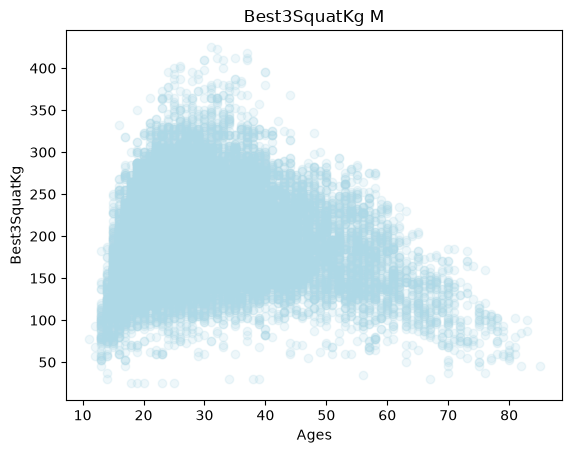

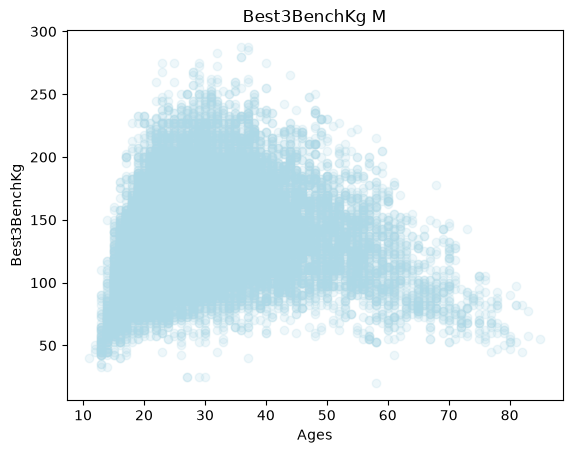

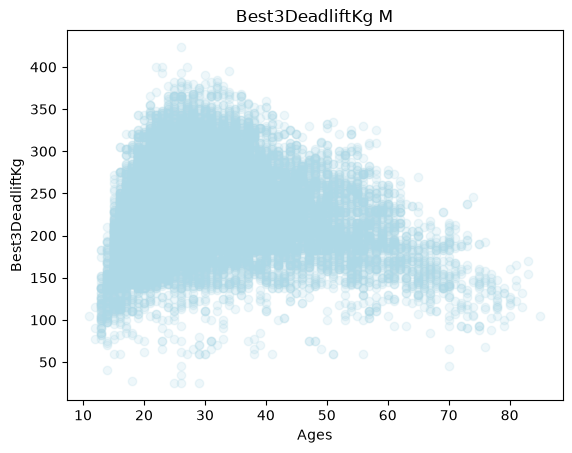

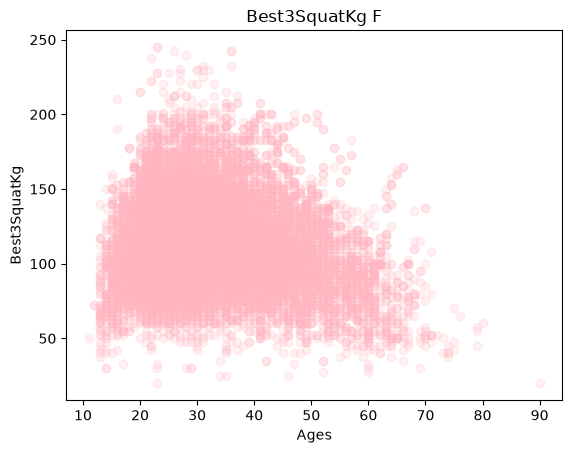

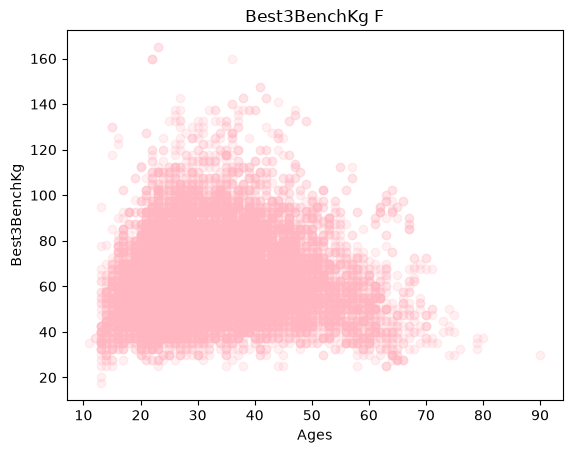

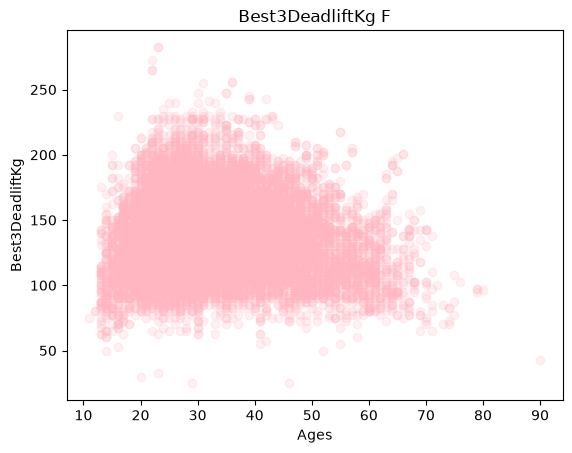

In [5]:
for s in ['M','F']:
    for lift in ['Best3SquatKg','Best3BenchKg','Best3DeadliftKg']:
       if s == 'M':
        plt.scatter(df[df['Sex'] == s]['Age'],df[df['Sex'] == s][lift], color = 'lightblue', alpha=.2)
        plt.title(lift + " " + s)

        plt.xlabel('Ages')
        plt.ylabel(lift)

        plt.show() 
       else:
        plt.scatter(df[df['Sex'] == s]['Age'],df[df['Sex'] == s][lift], color = 'lightpink', alpha=.2)
        plt.title(lift + " " + s)

        plt.xlabel('Ages')
        plt.ylabel(lift)

        plt.show() 

### Boxplot

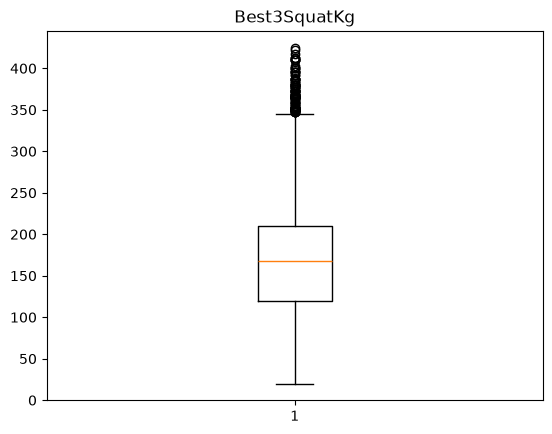

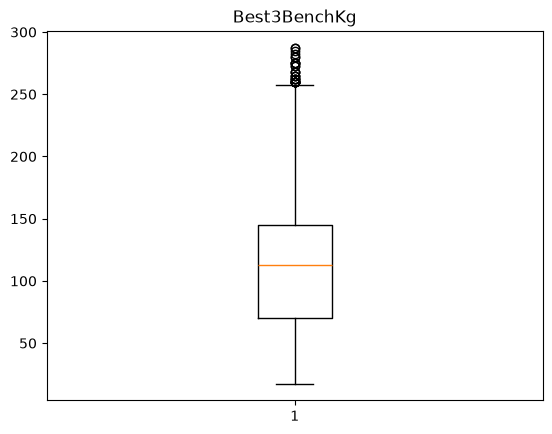

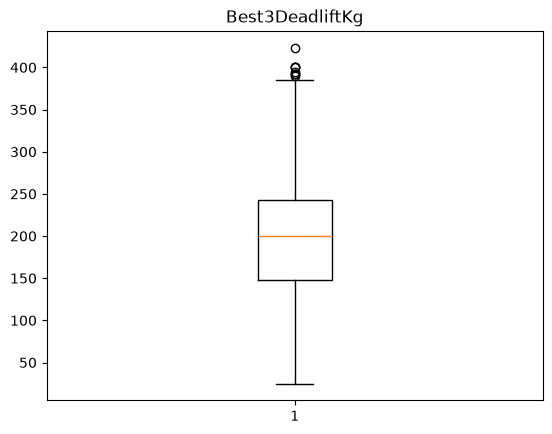

In [6]:
for lift in ['Best3SquatKg','Best3BenchKg','Best3DeadliftKg']:
    plt.boxplot(df[lift])
    plt.title(lift)
    plt.show()

### Correlation
- Using the pandas `df[[columns]].corr()` method, we notice correlations between lifts, bodyweight and ages.
    - The correlation between lifts (ie. best3squat and best3deadlift) mostly have a high positive correlation
        - a high deadlift means a high squat, etc.
    - A positive correlation between bodyweight and each lift
    - No correlation between the lift and the age of the lifter.

#### Method Function:
- `.corr()` uses the built in pandas method to find the positive or negative correlation between two values.
    - +1 correlation means that the data has a **perfect** correlation to each other
    - 0 correlation means that they have **no** correlation to each other
    - -1 correlation means that they have an **inverse** correlation to each other

In [7]:
df[['Best3SquatKg','Best3BenchKg','Best3DeadliftKg','BodyweightKg','Age']].corr()

,Best3SquatKg,Best3BenchKg,Best3DeadliftKg,BodyweightKg,Age
Best3SquatKg,1.000000,0.909705,0.926106,0.646186,-0.151260
Best3BenchKg,0.909705,1.000000,0.898006,0.652001,-0.066069
Best3DeadliftKg,0.926106,0.898006,1.000000,0.599060,-0.139855
BodyweightKg,0.646186,0.652001,0.599060,1.000000,0.085344
Age,-0.151260,-0.066069,-0.139855,0.085344,1.000000


## **Baseline Models**

### One Hot Encoder
- `OneHotEncoder` creates a binary 1/0 column and returns a matrix

### Standard Scaler
- `StandardScaler` Standardizes features by removing the mean and scaling to unit variance

### Column Transformer
- `ColumnTransformer()` transforms the column given the parameters you provide
    - ('name', transformer, columns)
        - *name* can be anything
        - *transformer* is the preprocessing methods we imported ie. standardscaler and onehotencoder
        - *columns* the columns in your dataset that you want to include

Best3SquatKg R2:  0.6532729744351126 MAE:  26.060557630919664 RMSE: 34.134176167695976


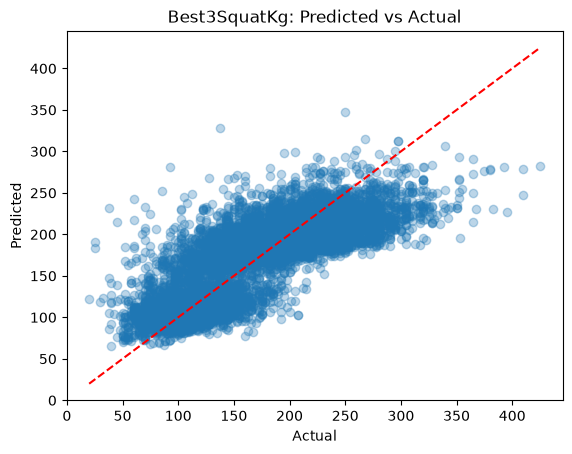

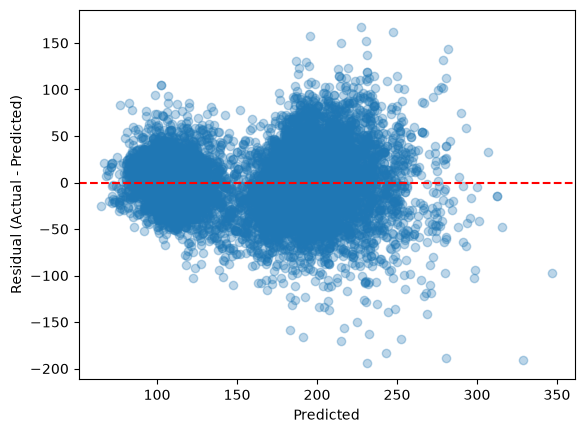

Best3BenchKg R2:  0.7256851140399965 MAE:  17.868879674587088 RMSE: 23.59218143430424


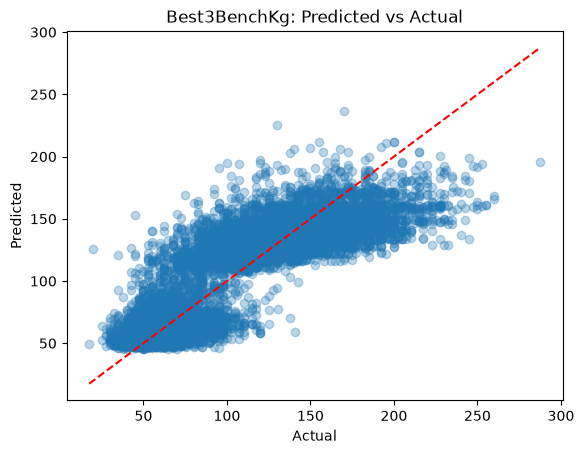

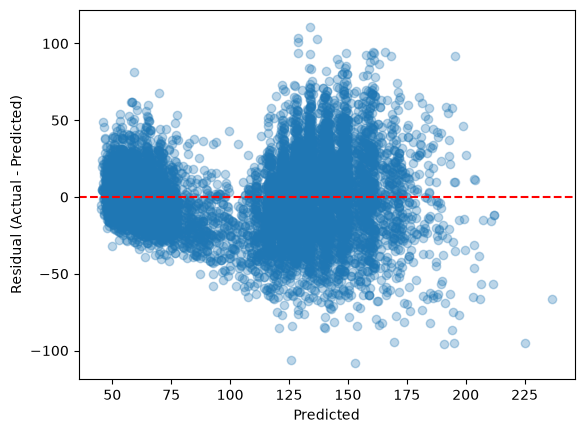

Best3DeadliftKg R2:  0.6686432208006577 MAE:  26.369405652604314 RMSE: 34.08632378024407


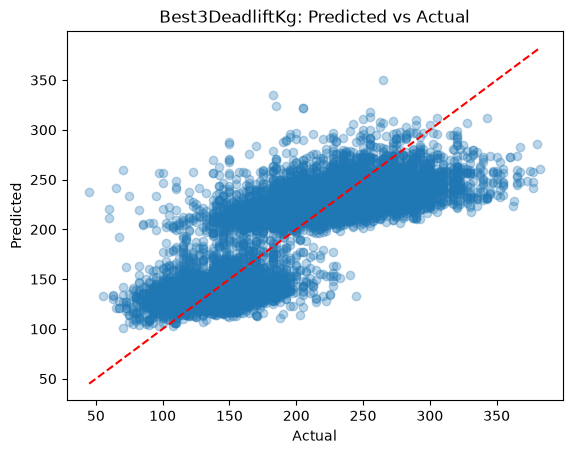

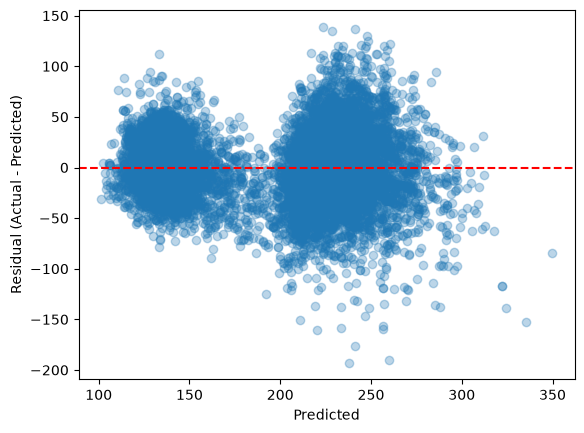

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


features = ['BodyweightKg', 'Age', 'Sex', 'Equipment']
targets = ['Best3SquatKg','Best3BenchKg','Best3DeadliftKg']

X = df[features]

prepocessor = ColumnTransformer([('num', RobustScaler(), ['BodyweightKg', 'Age']) , ('cat', OneHotEncoder(), ['Sex', 'Equipment'])])

X_train, X_test, y_train, y_test = train_test_split(X, df[targets], test_size=0.2, random_state=42)

models = {}

for t in targets:
    pipe = Pipeline([('prep', prepocessor), ('model', LinearRegression())])
    models[t] = pipe.fit(X_train, y_train[t])

    preds = models[t].predict(X_test)

    r2 = r2_score(y_test[t], preds)
    mae = mean_absolute_error(y_test[t], preds)
    rmse = np.sqrt(mean_squared_error(y_test[t], preds))

    print(t, 'R2: ', r2, 'MAE: ', mae, 'RMSE:', rmse)


    plt.scatter(y_test[t], preds, alpha=0.3)
    plt.plot([y_test[t].min(), y_test[t].max()], [y_test[t].min(), y_test[t].max()], 'r--')

    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{t}: Predicted vs Actual')

    plt.show()


    residuals = y_test[t] - preds
    plt.scatter(preds, residuals, alpha=0.3)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Predicted')
    plt.ylabel('Residual (Actual - Predicted)')
    
    plt.show()


    comparison = pd.DataFrame({'Actual': y_test[t].values, 'Predicted': preds})
    comparison.head(10)


